# Visual Product Search Engine — CLIP Fine-Tuning (Config C)

This notebook fine-tunes the CLIP vision encoder using contrastive learning.

---

### Goal
Push images of the **same item_id** closer in embedding space,
and push images of **different item_ids** farther apart.

---

### What we update
- Fine-tune CLIP **vision encoder** (last 4 transformer blocks)
- Keep CLIP **text encoder frozen** (as per project PDF)
- BLIP-2 stays frozen throughout

---

### Loss function
We use **InfoNCE contrastive loss** (same as original CLIP training).
Within each batch, images of the same item_id are positives,
all others are negatives.

---

### Inputs
- `yolo-bbox-crops-v1` — train crops + master_crops.csv
- `blipcaptionsoutput` — train_captions.json (for fused embeddings during fine-tuning)

### Outputs
- `clip_finetuned.pt` — fine-tuned CLIP vision encoder weights
- Training loss curve

## Step 1: Install and Import

In [1]:
!pip install ftfy regex transformers --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print('Libraries imported!')

Device : cuda
GPU    : Tesla T4
Libraries imported!


## Step 2: Config

In [3]:
# ============================================================
#  SET YOUR SEED (use one of your roll numbers)
# ============================================================
SEED = 550  # team roll number
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CROPS_DATASET    = '/kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1'
CAPTIONS_DATASET = '/kaggle/input/datasets/harshitabansal307/blipcaptionsoutput'
OUTPUT_DIR       = '/kaggle/working'

CLIP_MODEL_NAME  = 'openai/clip-vit-base-patch32'

# Training hyperparameters
EPOCHS          = 10      # 10 epochs: strong convergence within T4 time budget
BATCH_SIZE      = 32      # pairs per batch — must be even
LR              = 1e-5    # small LR for fine-tuning
TEMPERATURE     = 0.07    # InfoNCE temperature
N_BLOCKS_UNFREEZE = 4     # unfreeze last N transformer blocks of vision encoder

# Alpha for fused embedding during training
ALPHA_TRAIN     = 0.7     # same as best Config B alpha

for label, path in [('CROPS_DATASET', CROPS_DATASET), ('CAPTIONS_DATASET', CAPTIONS_DATASET)]:
    status = 'Found ✓' if os.path.exists(path) else 'NOT FOUND ✗'
    print(f'[{status}] {label}')

print(f'\nSeed            : {SEED}')
print(f'Epochs          : {EPOCHS}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Learning rate   : {LR}')
print(f'Blocks unfrozen : last {N_BLOCKS_UNFREEZE}')

[Found ✓] CROPS_DATASET
[Found ✓] CAPTIONS_DATASET

Seed            : 550
Epochs          : 10
Batch size      : 32
Learning rate   : 1e-05
Blocks unfrozen : last 4


## Step 3: Load Train Data and Captions

In [4]:
master_df = pd.read_csv(os.path.join(CROPS_DATASET, 'master_crops.csv'))
train_df  = master_df[master_df['split'] == 'train'].reset_index(drop=True)

def remap_path(old_path):
    if pd.isna(old_path):
        return old_path
    relative = old_path.replace('/kaggle/working/', '').replace('/kaggle/input/', '')
    for ds in ['yolocroppeddataset/', 'yolo-bbox-crops-v1/', 'datasets/harshitabansal307/yolo-bbox-crops-v1/']:
        relative = relative.replace(ds, '')
    return os.path.join(CROPS_DATASET, relative)

train_df['crop_path_new'] = train_df['crop_path'].apply(remap_path)
train_df['crop_exists']   = train_df['crop_path_new'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

if train_df['crop_exists'].sum() < len(train_df) * 0.9:
    def direct_path(image_name):
        relative = image_name[4:] if image_name.startswith('img/') else image_name
        for subdir in ['data/bbox_crops', 'data/yolo_crops']:
            p = os.path.join(CROPS_DATASET, subdir, relative)
            if os.path.exists(p):
                return p
        return os.path.join(CROPS_DATASET, 'data/bbox_crops', relative)
    train_df['crop_path_new'] = train_df['image_name'].apply(direct_path)
    train_df['crop_exists']   = train_df['crop_path_new'].apply(os.path.exists)

valid_train_df = train_df[train_df['crop_exists']].reset_index(drop=True)

# Load train captions
with open(os.path.join(CAPTIONS_DATASET, 'train_captions.json')) as f:
    train_captions = json.load(f)

print(f'Train images    : {len(valid_train_df):,}')
print(f'Train captions  : {len(train_captions):,}')
print(f'Unique item_ids : {valid_train_df["item_id"].nunique():,}')

Train images    : 25,882
Train captions  : 25,882
Unique item_ids : 3,997


## Step 4: Build Pair Dataset

For contrastive learning we need pairs of images from the same item_id (positives).
Within each batch, same-item pairs are positives, cross-item pairs are negatives.

In [5]:
class FashionPairDataset(Dataset):
    """
    Returns pairs of images from the same item_id.
    Each __getitem__ returns (anchor_image, positive_image, item_id).
    """
    def __init__(self, df, captions, processor):
        self.processor = processor
        self.captions  = captions

        # Group images by item_id — only keep items with >= 2 images
        grouped = df.groupby('item_id')
        self.pairs = []
        for item_id, group in grouped:
            paths = group['crop_path_new'].tolist()
            names = group['image_name'].tolist()
            if len(paths) >= 2:
                # Generate all pairs for this item
                for i in range(len(paths)):
                    for j in range(i + 1, len(paths)):
                        self.pairs.append({
                            'anchor_path'  : paths[i],
                            'positive_path': paths[j],
                            'anchor_name'  : names[i],
                            'positive_name': names[j],
                            'item_id'      : item_id
                        })

        random.shuffle(self.pairs)
        print(f'Dataset: {len(self.pairs):,} positive pairs from {df["item_id"].nunique():,} items')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        try:
            anchor   = Image.open(pair['anchor_path']).convert('RGB')
            positive = Image.open(pair['positive_path']).convert('RGB')
        except:
            # Fallback to first pair
            pair     = self.pairs[0]
            anchor   = Image.open(pair['anchor_path']).convert('RGB')
            positive = Image.open(pair['positive_path']).convert('RGB')

        # Process images
        anchor_inputs   = self.processor(images=anchor,   return_tensors='pt')
        positive_inputs = self.processor(images=positive, return_tensors='pt')

        return {
            'anchor_pixel_values'  : anchor_inputs['pixel_values'].squeeze(0),
            'positive_pixel_values': positive_inputs['pixel_values'].squeeze(0),
            'item_id'              : str(pair['item_id'])
        }

## Step 5: Load CLIP and Set Up Fine-Tuning

In [6]:
print('Loading CLIP...')
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)

# Step 1: Freeze everything first
for param in clip_model.parameters():
    param.requires_grad = False

# Step 2: Unfreeze last N blocks of vision encoder only
# Text encoder stays frozen as per project PDF
vision_encoder = clip_model.vision_model
total_blocks   = len(vision_encoder.encoder.layers)
unfreeze_from  = total_blocks - N_BLOCKS_UNFREEZE

for i, block in enumerate(vision_encoder.encoder.layers):
    if i >= unfreeze_from:
        for param in block.parameters():
            param.requires_grad = True

# Also unfreeze the post-layer norm
for param in vision_encoder.post_layernorm.parameters():
    param.requires_grad = True
for param in clip_model.visual_projection.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in clip_model.parameters())

print(f'Total vision encoder blocks : {total_blocks}')
print(f'Unfrozen blocks             : last {N_BLOCKS_UNFREEZE} (blocks {unfreeze_from} to {total_blocks-1})')
print(f'Trainable parameters        : {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)')
print('Text encoder                : FROZEN ✓')

Loading CLIP...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total vision encoder blocks : 12
Unfrozen blocks             : last 4 (blocks 8 to 11)
Trainable parameters        : 28,746,240 / 151,277,313  (19.0%)
Text encoder                : FROZEN ✓


In [7]:
# Build dataset and dataloader
train_dataset = FashionPairDataset(valid_train_df, train_captions, clip_processor)
train_loader  = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Optimizer — only updates trainable params
optimizer = torch.optim.AdamW(
    [p for p in clip_model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01
)

# Cosine LR scheduler
total_steps = EPOCHS * len(train_loader)
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f'Dataset pairs   : {len(train_dataset):,}')
print(f'Batches/epoch   : {len(train_loader):,}')
print(f'Total steps     : {total_steps:,}')

Dataset: 153,115 positive pairs from 3,997 items
Dataset pairs   : 153,115
Batches/epoch   : 4,785
Total steps     : 47,850


## Step 6: Define InfoNCE Loss

In [8]:
def infonce_loss(anchor_emb, positive_emb, temperature=TEMPERATURE):
    """
    InfoNCE contrastive loss.
    anchor_emb   : (B, D) normalised embeddings
    positive_emb : (B, D) normalised embeddings of positive pairs
    Within the batch, (anchor[i], positive[i]) is a positive pair.
    All other combinations are negatives.
    """
    # Similarity matrix: (B, B)
    sim_matrix = torch.matmul(anchor_emb, positive_emb.T) / temperature

    # Labels: diagonal is the correct positive pair
    labels = torch.arange(sim_matrix.shape[0], device=DEVICE)

    # Cross entropy in both directions then average
    loss_anchor  = F.cross_entropy(sim_matrix, labels)
    loss_positive = F.cross_entropy(sim_matrix.T, labels)
    return (loss_anchor + loss_positive) / 2


print('InfoNCE loss defined ✓')

InfoNCE loss defined ✓


## Step 7: Training Loop

In [9]:
clip_model.train()

epoch_losses = []
best_loss    = float('inf')

print(f'Starting fine-tuning for {EPOCHS} epochs...')
print(f'Temperature : {TEMPERATURE}')
print(f'Alpha train : {ALPHA_TRAIN}  (image-text fusion during training)')
print()

for epoch in range(EPOCHS):
    running_loss = 0.0
    n_batches    = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for batch in pbar:
        anchor_pixels   = batch['anchor_pixel_values'].to(DEVICE)
        positive_pixels = batch['positive_pixel_values'].to(DEVICE)

        # Get image embeddings from vision encoder
        _a = clip_model.get_image_features(pixel_values=anchor_pixels)
        anchor_img_emb = _a.pooler_output if hasattr(_a, 'pooler_output') and not isinstance(_a, torch.Tensor) else _a
        _p = clip_model.get_image_features(pixel_values=positive_pixels)
        positive_img_emb = _p.pooler_output if hasattr(_p, 'pooler_output') and not isinstance(_p, torch.Tensor) else _p

        # L2 normalise
        anchor_img_emb   = anchor_img_emb   / anchor_img_emb.norm(dim=-1, keepdim=True)
        positive_img_emb = positive_img_emb / positive_img_emb.norm(dim=-1, keepdim=True)

        # Compute InfoNCE loss
        loss = infonce_loss(anchor_img_emb, positive_img_emb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clip_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        n_batches    += 1
        pbar.set_postfix({'loss': f'{running_loss/n_batches:.4f}'})

    epoch_loss = running_loss / n_batches
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.4f}')

    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(
            clip_model.vision_model.state_dict(),
            '/kaggle/working/clip_finetuned_vision.pt'
        )
        # Also save the full model state dict for easy loading
        torch.save(
            clip_model.state_dict(),
            '/kaggle/working/clip_finetuned_full.pt'
        )
        print(f'  Best model saved (loss={best_loss:.4f})')

print(f'\nTraining complete! Best loss: {best_loss:.4f}')

Starting fine-tuning for 10 epochs...
Temperature : 0.07
Alpha train : 0.7  (image-text fusion during training)



Epoch 1/10: 100%|██████████| 4785/4785 [26:30<00:00,  3.01it/s, loss=0.3702]


Epoch 1/10 — Loss: 0.3702
  Best model saved (loss=0.3702)


Epoch 2/10: 100%|██████████| 4785/4785 [25:39<00:00,  3.11it/s, loss=0.2551]


Epoch 2/10 — Loss: 0.2551
  Best model saved (loss=0.2551)


...

Epoch 8/10 — Loss: 0.2282


Epoch 9/10: 100%|██████████| 4785/4785 [25:29<00:00,  3.13it/s, loss=0.2254]


Epoch 9/10 — Loss: 0.2254
  Best model saved (loss=0.2254)


Epoch 10/10: 100%|██████████| 4785/4785 [25:28<00:00,  3.13it/s, loss=0.2275]

Epoch 10/10 — Loss: 0.2275

Training complete! Best loss: 0.2254


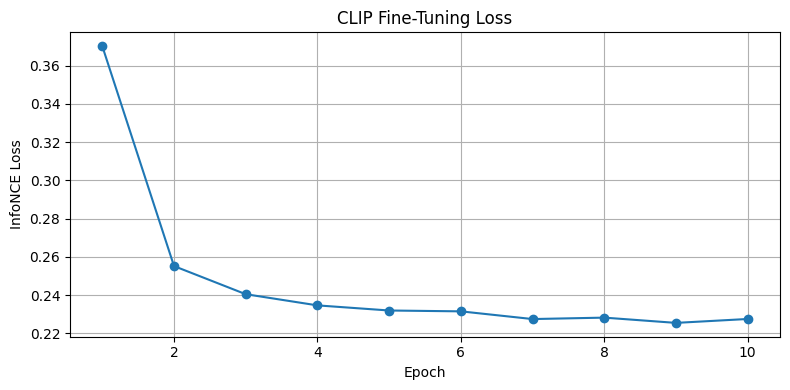

Training curve saved!


In [10]:
# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('CLIP Fine-Tuning Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curve.png', dpi=100)
plt.show()
print('Training curve saved!')

## Step 8: Build Config C Index Using Fine-Tuned CLIP

Now re-encode gallery images with the fine-tuned model and build new FAISS indexes.

In [11]:
!pip uninstall -y faiss faiss-gpu
!pip install faiss-cpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 67.8 MB/s eta 0:00:00


In [12]:
import faiss

# Load gallery data
gallery_df = master_df[master_df['split'] == 'gallery'].reset_index(drop=True)

def remap_path(old_path):
    if pd.isna(old_path):
        return old_path
    relative = old_path.replace('/kaggle/working/', '').replace('/kaggle/input/', '')
    for ds in ['yolocroppeddataset/', 'yolo-bbox-crops-v1/', 'datasets/harshitabansal307/yolo-bbox-crops-v1/']:
        relative = relative.replace(ds, '')
    return os.path.join(CROPS_DATASET, relative)

gallery_df['crop_path_new'] = gallery_df['crop_path'].apply(remap_path)
gallery_df['crop_exists']   = gallery_df['crop_path_new'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)
valid_gallery = gallery_df[gallery_df['crop_exists']].reset_index(drop=True)

# Load gallery captions
with open(os.path.join(CAPTIONS_DATASET, 'gallery_captions.json')) as f:
    gallery_captions = json.load(f)

# Load fine-tuned model
clip_model.load_state_dict(torch.load('/kaggle/working/clip_finetuned_full.pt'))
clip_model.eval()

EMBED_DIM  = clip_model.config.projection_dim
BATCH_SIZE_EMB = 64
n_gallery  = len(valid_gallery)

print(f'Re-encoding {n_gallery:,} gallery images with fine-tuned CLIP...')

ft_image_embs = np.zeros((n_gallery, EMBED_DIM), dtype=np.float32)
ft_text_embs  = np.zeros((n_gallery, EMBED_DIM), dtype=np.float32)

for batch_start in tqdm(range(0, n_gallery, BATCH_SIZE_EMB), desc='Gallery re-encoding'):
    batch = valid_gallery.iloc[batch_start : batch_start + BATCH_SIZE_EMB]

    # Image embeddings
    images = []
    valid_idx = []
    for i, (_, row) in enumerate(batch.iterrows()):
        try:
            images.append(Image.open(row['crop_path_new']).convert('RGB'))
            valid_idx.append(i)
        except:
            pass
    if images:
        inputs = clip_processor(images=images, return_tensors='pt', padding=True).to(DEVICE)
        with torch.no_grad():
            _out = clip_model.get_image_features(**inputs)
            feats = _out.pooler_output if hasattr(_out, 'pooler_output') and not isinstance(_out, torch.Tensor) else _out
        feats = feats / feats.norm(dim=-1, keepdim=True)
        for local_i, global_i in enumerate(valid_idx):
            ft_image_embs[batch_start + global_i] = feats[local_i].cpu().numpy()

    # Text embeddings
    texts = [gallery_captions.get(row['image_name'], 'a clothing item') for _, row in batch.iterrows()]
    t_inputs = clip_processor(
        text=texts, return_tensors='pt', padding=True, truncation=True, max_length=77
    ).to(DEVICE)
    with torch.no_grad():
        _tout = clip_model.get_text_features(**t_inputs)
        t_feats = _tout.pooler_output if hasattr(_tout, 'pooler_output') and not isinstance(_tout, torch.Tensor) else _tout
    t_feats = t_feats / t_feats.norm(dim=-1, keepdim=True)
    ft_text_embs[batch_start : batch_start + len(texts)] = t_feats.cpu().numpy()

print('Re-encoding done!')

# Build Config C indexes for two alpha values
for alpha in [0.7, 0.5]:
    fused = alpha * ft_image_embs + (1 - alpha) * ft_text_embs
    norms = np.linalg.norm(fused, axis=-1, keepdims=True)
    fused = fused / np.maximum(norms, 1e-8)

    alpha_str = f'alpha{int(alpha*10):02d}'
    np.save(f'/kaggle/working/gallery_embeddings_C_{alpha_str}.npy', fused)

    index = faiss.IndexFlatIP(EMBED_DIM)
    index.add(fused.astype(np.float32))
    faiss.write_index(index, f'/kaggle/working/faiss_index_C_{alpha_str}.bin')
    print(f'Config C index built: alpha={alpha}, vectors={index.ntotal:,}')

print('\nAll Config C indexes saved!')

Re-encoding 12,612 gallery images with fine-tuned CLIP...


Gallery re-encoding: 100%|██████████| 198/198 [02:21<00:00,  1.39it/s]


Re-encoding done!
Config C index built: alpha=0.7, vectors=12,612
Config C index built: alpha=0.5, vectors=12,612

All Config C indexes saved!


## Step 9: Final Summary

In [13]:
print('=' * 60)
print('       CLIP FINE-TUNING + CONFIG C INDEXING COMPLETE')
print('=' * 60)
print(f'  CLIP model          : {CLIP_MODEL_NAME}')
print(f'  Epochs trained      : {EPOCHS}')
print(f'  Best training loss  : {best_loss:.4f}')
print(f'  Blocks unfrozen     : last {N_BLOCKS_UNFREEZE}')
print(f'  Text encoder        : FROZEN throughout')
print()
print('  Files saved:')
for f in sorted(os.listdir('/kaggle/working')):
    if f.endswith(('.pt', '.bin', '.npy', '.png', '.csv')):
        size = os.path.getsize(f'/kaggle/working/{f}') / 1e6
        print(f'    {f}  ({size:.1f} MB)')
print()
print('  Next step:')
print('    Save as Kaggle dataset (clip-finetuned-indexes-c)')
print('    Run evaluation notebook with Config C indexes')
print('=' * 60)

       CLIP FINE-TUNING + CONFIG C INDEXING COMPLETE
  CLIP model          : openai/clip-vit-base-patch32
  Epochs trained      : 10
  Best training loss  : 0.2254
  Blocks unfrozen     : last 4
  Text encoder        : FROZEN throughout

  Files saved:
    clip_finetuned_full.pt  (605.3 MB)
    clip_finetuned_vision.pt  (349.9 MB)
    faiss_index_C_alpha05.bin  (25.8 MB)
    faiss_index_C_alpha07.bin  (25.8 MB)
    gallery_embeddings_C_alpha05.npy  (25.8 MB)
    gallery_embeddings_C_alpha07.npy  (25.8 MB)
    training_curve.png  (0.0 MB)

  Next step:
    Save as Kaggle dataset (clip-finetuned-indexes-c)
    Run evaluation notebook with Config C indexes
